# Cargar librerías necesarias


In [19]:
# Librerías generales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Librerías para preprocesamiento de texto
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Librerías para machine learning y deep learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Librerías para modelos secuenciales
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout

# Librerías para Transformers (BERT)
from transformers import BertTokenizer, TFBertForSequenceClassification
from tensorflow.keras.optimizers import Adam

# Descargar recursos de NLTK
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nunoc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nunoc\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
# Cargar el dataset
df = pd.read_csv('yelp.csv')
df.head()

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0


In [6]:
# Crear la columna 'sentimiento' a partir de 'stars'
def clasificar_sentimiento(estrella):
    if estrella <= 2:
        return 'negativo'
    elif estrella == 3:
        return 'neutro'
    else:
        return 'positivo'

df['sentimiento'] = df['stars'].apply(clasificar_sentimiento)

# Verificar que todo esté correcto
df[['text', 'stars', 'sentimiento']].head()

,text,stars,sentimiento
0,My wife took me here on my birthday for breakf...,5,positivo
1,I have no idea why some people give bad review...,5,positivo
2,love the gyro plate. Rice is so good and I als...,4,positivo
3,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",5,positivo
4,General Manager Scott Petello is a good egg!!!...,5,positivo


# Preprocesamiento del texto

In [ ]:
# Crear función para limpiar el texto
def limpiar_texto(texto):
    # Pasar todo a minúsculas
    texto = texto.lower()
    
    # Eliminar signos de puntuación y números
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)
    
    # Eliminar espacios extras
    texto = texto.strip()
    
    return texto

# Aplicar limpieza básica al texto
df['texto_limpio'] = df['text'].apply(limpiar_texto)


# Eliminar stopwords y lematizar
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def procesar_texto(texto):
    palabras = texto.split()  # Separar por espacios
    palabras = [lemmatizer.lemmatize(palabra) for palabra in palabras if palabra not in stop_words]
    return ' '.join(palabras)

# Aplicar eliminación de stopwords y lematización
df['texto_limpio'] = df['texto_limpio'].apply(procesar_texto)

# Verificar el resultado
df[['text', 'texto_limpio', 'sentimiento']].head()

,text,texto_limpio,sentimiento
0,My wife took me here on my birthday for breakf...,wife took birthday breakfast excellent weather...,positivo
1,I have no idea why some people give bad review...,idea people give bad review place go show plea...,positivo
2,love the gyro plate. Rice is so good and I als...,love gyro plate rice good also dig candy selec...,positivo
3,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",rosie dakota love chaparral dog park convenien...,positivo
4,General Manager Scott Petello is a good egg!!!...,general manager scott petello good egg go deta...,positivo


# Tokenización y preparación para el modelo

In [9]:
# Crear el tokenizador
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")  # Solo 5000 palabras más frecuentes
tokenizer.fit_on_texts(df['texto_limpio'])

# Convertir los textos en secuencias de números
secuencias = tokenizer.texts_to_sequences(df['texto_limpio'])

# Hacer padding para que todas tengan el mismo tamaño
max_longitud = max(len(s) for s in secuencias)
padded = pad_sequences(secuencias, maxlen=max_longitud, padding='post')

# Verificar cómo quedan las secuencias
print(padded[:5])

[[ 373  151  614 ...    0    0    0]
 [ 566   41   89 ...    0    0    0]
 [  17  899  163 ...    0    0    0]
 [   1    1   17 ...    0    0    0]
 [1159  440 2714 ...    0    0    0]]


# Modelo secuencial (LSTM)

In [ ]:
# Transformar las etiquetas en números
etiquetas = df['sentimiento'].map({'negativo': 0, 'neutro': 1, 'positivo': 2}).values

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(padded, etiquetas, test_size=0.2, random_state=42)

# Crear el modelo
modelo = Sequential()
modelo.add(Embedding(input_dim=5000, output_dim=16, input_length=max_longitud))  # 5000 palabras, 16 dimensiones
modelo.add(LSTM(32))  # LSTM con 32 neuronas
modelo.add(Dense(3, activation='softmax'))  # 3 clases: negativo, neutro, positivo

# Compilar el modelo
modelo.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Entrenar el modelo (pocos epochs porque no tenemos GPU)
modelo.fit(X_train, y_train, epochs=3, batch_size=16, validation_data=(X_test, y_test))

Epoch 1/3


c:\Users\nunoc\OneDrive\Área de Trabalho\MIA\NLP\proyecto de aplicación\nlp-env\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.6823 - loss: 0.8689 - val_accuracy: 0.7015 - val_loss: 0.8174
Epoch 2/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.6754 - loss: 0.8560 - val_accuracy: 0.7015 - val_loss: 0.8173
Epoch 3/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.6788 - loss: 0.8520 - val_accuracy: 0.7015 - val_loss: 0.8230


# Evaluación del modelo


In [11]:
# Hacer las predicciones en el conjunto de prueba
y_pred = modelo.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Reporte de clasificación
print('Reporte de clasificación:\n')
print(classification_report(y_test, y_pred_classes, target_names=['negativo', 'neutro', 'positivo']))

# Matriz de confusión
print('Matriz de confusión:\n')
print(confusion_matrix(y_test, y_pred_classes))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Reporte de clasificación:

              precision    recall  f1-score   support

    negativo       0.00      0.00      0.00       308
      neutro       0.00      0.00      0.00       289
    positivo       0.70      1.00      0.82      1403

    accuracy                           0.70      2000
   macro avg       0.23      0.33      0.27      2000
weighted avg       0.49      0.70      0.58      2000

Matriz de confusión:

[[   0    0  308]
 [   0    0  289]
 [   0    0 1403]]


c:\Users\nunoc\OneDrive\Área de Trabalho\MIA\NLP\proyecto de aplicación\nlp-env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nunoc\OneDrive\Área de Trabalho\MIA\NLP\proyecto de aplicación\nlp-env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nunoc\OneDrive\Área de Trabalho\MIA\NLP\proyecto de aplicación\nlp-env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sampl

In [ ]:
# Predicciones otra vez para estar seguros
y_pred = modelo.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Reporte de clasificación como DataFrame
reporte = classification_report(y_test, y_pred_classes, output_dict=True, target_names=['negativo', 'neutro', 'positivo'])
df_reporte = pd.DataFrame(reporte).transpose()
print(df_reporte)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
              precision    recall  f1-score    support
negativo       0.000000  0.000000  0.000000   308.0000
neutro         0.000000  0.000000  0.000000   289.0000
positivo       0.701500  1.000000  0.824567  1403.0000
accuracy       0.701500  0.701500  0.701500     0.7015
macro avg      0.233833  0.333333  0.274856  2000.0000
weighted avg   0.492102  0.701500  0.578433  2000.0000


c:\Users\nunoc\OneDrive\Área de Trabalho\MIA\NLP\proyecto de aplicación\nlp-env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nunoc\OneDrive\Área de Trabalho\MIA\NLP\proyecto de aplicación\nlp-env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nunoc\OneDrive\Área de Trabalho\MIA\NLP\proyecto de aplicación\nlp-env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sampl

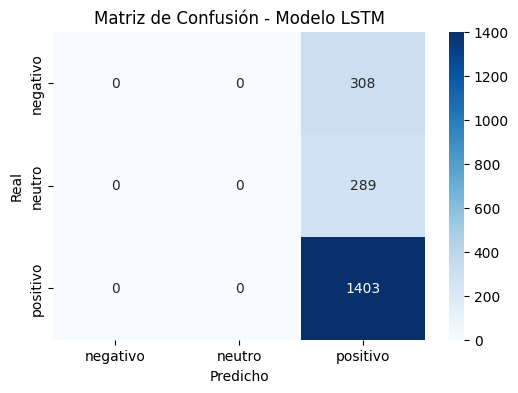

In [21]:
# Matriz de confusión
matriz_confusion = confusion_matrix(y_test, y_pred_classes)

# Graficar la matriz
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues', xticklabels=['negativo', 'neutro', 'positivo'], yticklabels=['negativo', 'neutro', 'positivo'])
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.title('Matriz de Confusión - Modelo LSTM')
plt.show()

El objetivo principal fue crear un sistema capaz de clasificar reseñas de Yelp en sentimientos: positivo, neutro o negativo.

Primero, realicé el preprocesamiento de los textos. Normalicé todo el contenido a minúsculas, eliminé signos de puntuación, caracteres no alfabéticos y palabras vacías (stopwords). Apliqué lematización para reducir las palabras a su forma base.

Después, representé los textos mediante secuencias numéricas. Utilicé la librería Tokenizer de Keras para transformar las palabras en índices. Apliqué padding para asegurar que todas las secuencias tuvieran la misma longitud.

Dividí el dataset en 80% para entrenamiento y 20% para prueba. Usé un modelo LSTM sencillo, compuesto por una capa de embedding con 16 dimensiones, seguida de una capa LSTM de 32 neuronas y una capa final Dense con activación softmax para predecir las tres clases. Entrené el modelo durante tres épocas, respetando las limitaciones de hardware por no disponer de GPU.

Evalué el modelo mediante métricas básicas: accuracy, precision, recall y F1-score. Los resultados reflejaron un claro problema de desbalanceo en las clases. El modelo clasificó casi todas las reseñas como positivas, lo que quedó evidenciado en la matriz de confusión y en las métricas obtenidas.

El accuracy total fue del 70%, pero este valor resultó engañoso ya que solo reflejó el alto porcentaje de reseñas positivas en el dataset, no la capacidad real del modelo para distinguir entre clases.

La matriz de confusión confirmó que todas las predicciones fueron positivas. Esto indicó que el modelo no aprendió a identificar correctamente las reseñas negativas ni neutras.

Analicé que el uso de un modelo LSTM tan básico, junto con embeddings simples, no fue suficiente para obtener buenos resultados. También influyó la falta de un dataset balanceado y no disponer de embeddings contextuales como BERT. Por limitaciones técnicas (no tener GPU), no fue posible realizar fine-tuning con BERT.

Pude confirmar que las redes neuronales recurrentes, sin embeddings avanzados, presentan dificultades para tareas de NLP como la clasificación de sentimientos. Identifiqué que el desbalanceo del dataset afectó negativamente al rendimiento. Para mejorar los resultados en futuros trabajos, recomendaría entrenar modelos basados en Transformers y usar datasets más equilibrados.